In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker 
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:
#Set proffesional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0.15, 0.85, 5))

primary_color   = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color    = viridis_colors[2]
neutral_color   = viridis_colors[4]
danger_color = '#E76F51'

custom_palette = viridis_colors

In [3]:
df = pd.read_csv(r'C:\Users\admin\Documents\SupplyChainDataset.csv', encoding = 'latin1')

# Exploratory Data Analysis (EDA)

In [4]:
print('rows, cols:', df.shape)
print('\ncolumns;')
print(df.columns.tolist())
print('\nNum duplicates;', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df . isna().sum().sort_values(ascending = False). head(20))

rows, cols: (180519, 53)

columns;
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [5]:
# Data Cleaning

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Latitude',
    'Longitude',
    'Order Item Cardprod Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Id',
    'Order Item Product Price',
    'Order Item Quantity', 
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']
# # dropping columns that are either fully missing, redundant, or have only one value (and thus no varaince)
df = df.drop(columns=columns_to_drop)

#removing canceled orders since they are not relevant for delivery time analysis and may have different patterns that completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c],format='mixed',errors='coerce')
    
# after data cleaning, ;ets check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df. isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [6]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique()<10:
        print(f'n\{col} value counts:')
        print(df[col].value_counts())

n\Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64
n\Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64
n\Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64
n\Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64
n\Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64
n\Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64
n\Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64
n\Order Status value counts:
Order Status
CO

In [7]:
#calculating order processing time and delay
df ['Order Processing Time'] = (df ['shipping date (DateOrders)'] - df ['order date (DateOrders)']).dt.days
df ['Delay'] = df ['Order Processing Time'] - df ['Days for shipment (scheduled)']
df ['Is_Delayed'] = df ['Delay'] > 0
df ['order_month'] = df ['order date (DateOrders)'].dt.month
df ['order_day'] = df ['order date (DateOrders)'].dt.day_name()
df ['order_hour'] = df ['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [8]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [9]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [10]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [11]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where (df ['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss', 'Break_even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break_even      1116
Name: count, dtype: int64

In [12]:
df['Profitability Flag'].value_counts(normalize = True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break_even    0.00646
Name: proportion, dtype: float64

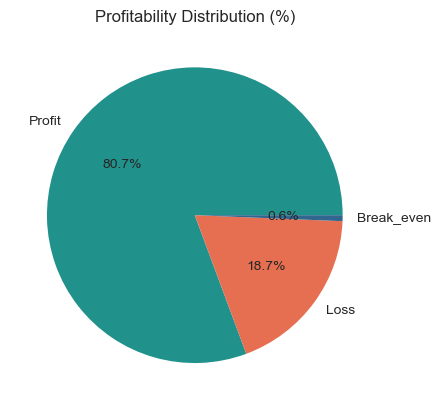

In [13]:
#visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize = True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()



In [14]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'(value:.0f) $'
delayed_df= df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df ['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay']> 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profibility vs Delivery Time Analysis

In [27]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
        .agg(
            mean_profit='mean',
            total_profit='sum',
            order_count='count'
        )
        .reset_index()
)

In [28]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [29]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index() * 100
).reset_index()

In [30]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


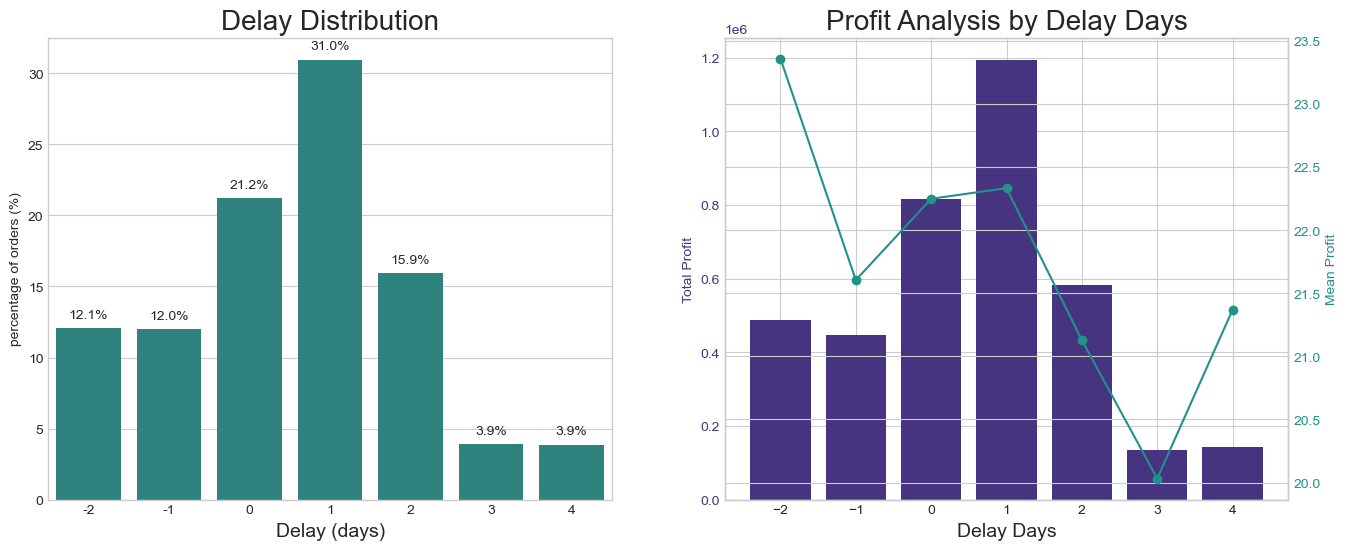

In [34]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution', fontsize = 20)
ax1.set_xlabel('Delay (days)', fontsize = 14)
ax1.set_ylabel('percentage of orders (%)')

#percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')
    
# Second subplot: Profit Analysis by Delay Days
ax2.set_title('Profit Analysis by Delay Days', fontsize = 20)
ax2.set_xlabel('Delay Days', fontsize = 14)
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics ['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3= ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Bottleneck Detection

In [20]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

In [21]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,30817,17060,55.359055
0,Consumer,89420,48855,54.635428
1,Corporate,52528,28608,54.462382


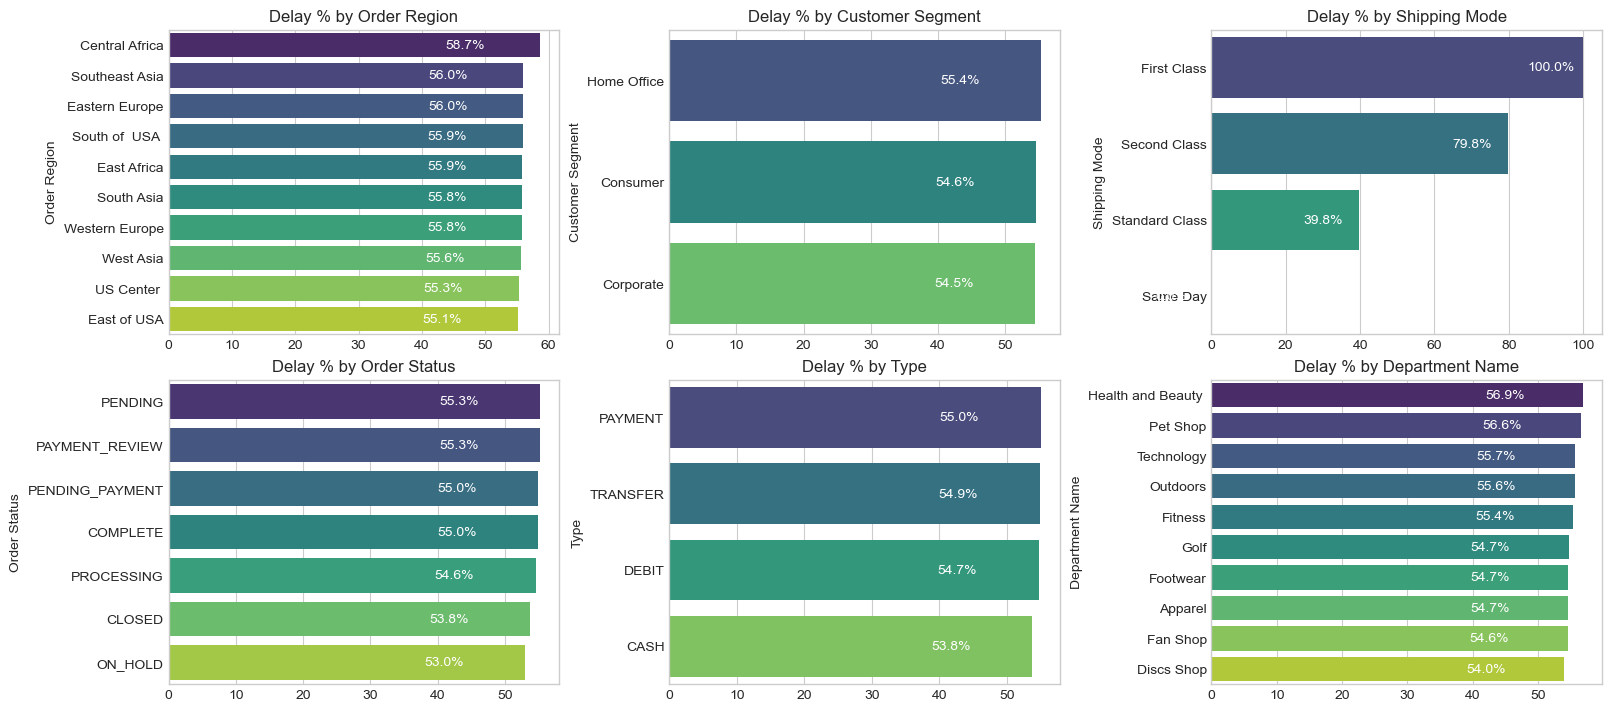

In [22]:
def compute_delay_pct_by_category(category):
    cat_df=df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df 
categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()
for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')
plt.show()

# Root Cause Analysis

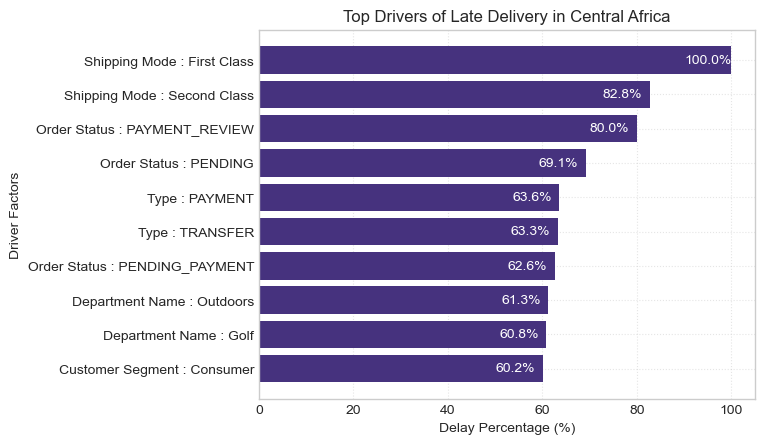

In [23]:
#Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name','Type', 'Order Status']
    
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby (factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
                .reset_index()
        )
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp ['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])
        
    # Combine all drivers
    final_df = pd.concat(all_factors)
    
    #Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va='center', fontsize = 10,color = 'white')
    plt.show()
top_drivers_for_region('Central Africa')

# Time-Based Analysis

In [24]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour') ['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [25]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


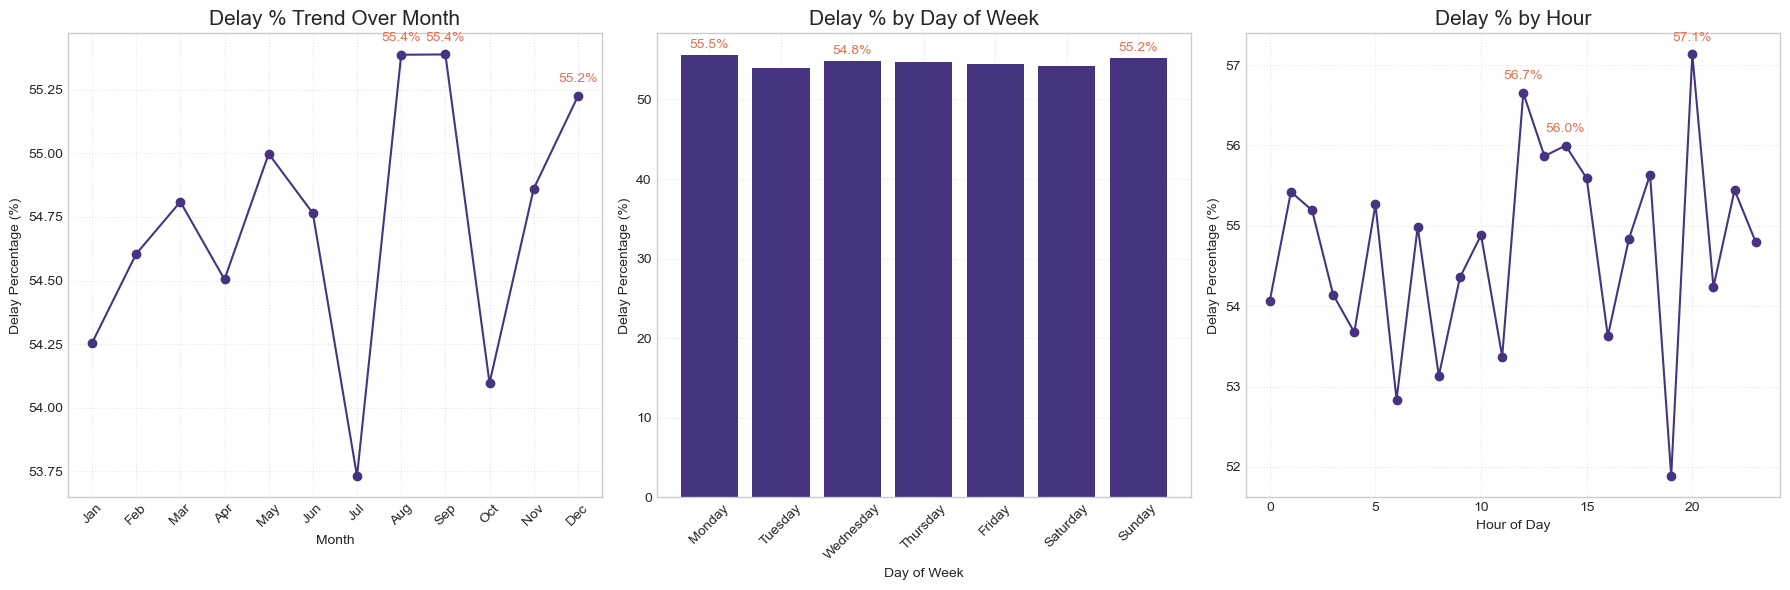

In [35]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month", fontsize = 15)
ax1.grid(True, linestyle = ':', alpha=0.5)
#Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

#Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week", fontsize = 15)
ax2.grid(True, linestyle=':', alpha=0.5)
    
# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour", fontsize = 15)
ax3.grid(True, linestyle=':', alpha=0.5)

#Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)
plt.tight_layout()
plt.show()